In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split , GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error , r2_score
from xgboost import XGBRegressor
import joblib

In [2]:
data = fetch_openml(data_id=42165, as_frame=True) 
data.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X = pd.DataFrame(data.data , columns=data.feature_names)
y = data.target

In [4]:
X.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,1,2008,WD,Normal


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [6]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include="object").columns

In [7]:
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

X_train[num_cols]= pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
X_test[num_cols] = pd.DataFrame(num_imputer.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)

X_train[cat_cols]= pd.DataFrame(cat_imputer.fit_transform(X_train[cat_cols]), columns=cat_cols, index=X_train.index)
X_test[cat_cols] = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), columns=cat_cols, index=X_test.index)

X_train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
6,7.0,20.0,RL,75.0,10084.0,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,0.0,Gd,MnPrv,Shed,0.0,8.0,2007.0,WD,Normal
807,808.0,70.0,RL,144.0,21384.0,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,0.0,Gd,MnPrv,Shed,0.0,5.0,2009.0,WD,Normal
955,956.0,90.0,RH,82.0,7136.0,Pave,Grvl,IR1,HLS,AllPub,...,0.0,0.0,Gd,MnPrv,Shed,0.0,8.0,2007.0,WD,Normal
1040,1041.0,20.0,RL,88.0,13125.0,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,0.0,Gd,GdPrv,Shed,0.0,1.0,2006.0,WD,Normal
701,702.0,20.0,RL,80.0,9600.0,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,0.0,Gd,MnPrv,Shed,0.0,7.0,2006.0,COD,Normal
303,304.0,20.0,RL,70.0,9800.0,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,0.0,Gd,GdWo,Shed,0.0,7.0,2006.0,WD,Abnorml
1264,1265.0,120.0,RH,34.0,4060.0,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,0.0,Gd,MnPrv,Shed,0.0,8.0,2008.0,COD,Abnorml
216,217.0,20.0,RL,65.0,8450.0,Pave,Grvl,Reg,Lvl,AllPub,...,0.0,0.0,Gd,MnPrv,Shed,0.0,4.0,2008.0,WD,Normal
1157,1158.0,120.0,RL,34.0,5001.0,Pave,Grvl,IR1,Lvl,AllPub,...,0.0,0.0,Gd,MnPrv,Shed,0.0,7.0,2009.0,WD,Normal
350,351.0,120.0,RL,68.0,7820.0,Pave,Grvl,IR1,Lvl,AllPub,...,0.0,0.0,Gd,MnPrv,Shed,0.0,12.0,2007.0,New,Partial


In [8]:
for col in cat_cols:
    X_train[col] = X_train[col].astype(str).str.strip()
    X_test[col] = X_test[col].astype(str).str.strip()

In [9]:
ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value" , unknown_value=-1)

X_train[cat_cols] = ordinal_encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = ordinal_encoder.transform(X_test[cat_cols])

X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
6,7.0,20.0,3.0,75.0,10084.0,1.0,0.0,3.0,3.0,0.0,...,0.0,0.0,2.0,2.0,2.0,0.0,8.0,2007.0,8.0,4.0
807,808.0,70.0,3.0,144.0,21384.0,1.0,0.0,3.0,3.0,0.0,...,0.0,0.0,2.0,2.0,2.0,0.0,5.0,2009.0,8.0,4.0
955,956.0,90.0,2.0,82.0,7136.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,2.0,2.0,2.0,0.0,8.0,2007.0,8.0,4.0
1040,1041.0,20.0,3.0,88.0,13125.0,1.0,0.0,3.0,3.0,0.0,...,0.0,0.0,2.0,0.0,2.0,0.0,1.0,2006.0,8.0,4.0
701,702.0,20.0,3.0,80.0,9600.0,1.0,0.0,3.0,3.0,0.0,...,0.0,0.0,2.0,2.0,2.0,0.0,7.0,2006.0,0.0,4.0


In [10]:
print(X_train.dtypes.value_counts())

float64    80
Name: count, dtype: int64


In [11]:
xgb_base = XGBRegressor(random_state=1)
xgb_base.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [12]:
y_pred = xgb_base.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mae

16397.564453125

In [14]:
r2 = r2_score(y_test, y_pred)
r2

0.9054790139198303

In [15]:
param_grid = {
    'max_depth': randint(3,10),
    'n_estimators': randint(100,400),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6,1),
    'colsample_bytree': uniform(0.6,1)
}

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [36]:
search = RandomizedSearchCV(
    xgb_base,
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1,
    n_iter=30,
    random_state=2
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....x722c6359b3e0>, 'learning_rate': <scipy.stats....x722c6359b080>, 'max_depth': <scipy.stats....x722c634e7b00>, 'n_estimators': <scipy.stats....x722c641b51c0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` 

In [37]:
search.best_score_

np.float64(0.8638282299041748)

In [38]:
search.best_params_

{'colsample_bytree': np.float64(0.9875234258732815),
 'learning_rate': np.float64(0.10941475974690253),
 'max_depth': 4,
 'n_estimators': 235,
 'subsample': np.float64(0.9508719013016405)}

In [39]:
best_params = search.best_params_

xgb_final = XGBRegressor(**best_params, random_state=2)
xgb_final.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.9875234258732815)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.dat

In [40]:
final_pred = xgb_final.predict(X_test)

final_mae = mean_absolute_error(y_test, final_pred)
final_mae

14999.748046875

In [66]:
importance = xgb_final.feature_importances_
imp_feat = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

In [67]:
top_k = 15
top_imp_feat = imp_feat.head(top_k)

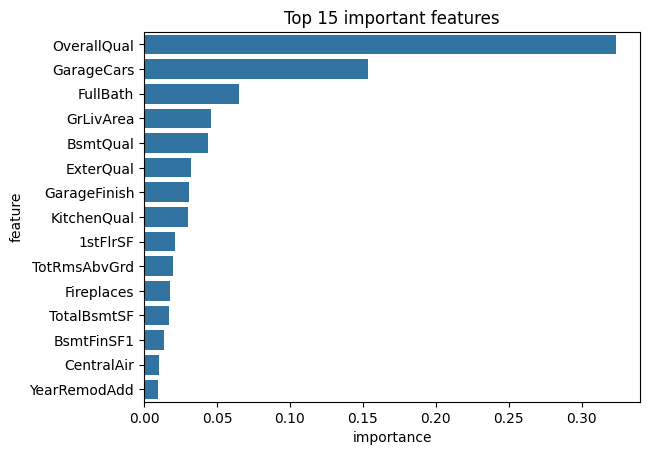

In [72]:
sns.barplot(
    data=top_imp_feat,
    x= 'importance',
    y= 'feature'
)
plt.title(f"Top {top_k} important features")
plt.show()

In [73]:
joblib.dump(xgb_final, "xgb_house_pricing_model.pkl")

['xgb_house_pricing_model.pkl']